# This jupyter notebook is prepared by "Savion J.G.".

## Section 1 - Load Data and perform General EDA

## Section 1.1 Import Libraries

In [140]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import missingno as msno
from scipy import stats
import sklearn

print("✓ All libraries imported successfully!")
print(f"pandas  : {pd.__version__}")
print(f"numpy   : {np.__version__}")
print(f"sklearn : {sklearn.__version__}")


✓ All libraries imported successfully!
pandas  : 3.0.1
numpy   : 2.4.2
sklearn : 1.8.0


## Section 1.2 Import the Dataset and Show row/columns Count (1 pt)

In [141]:
# Read the csv file into pandas dataframe
df = pd.read_csv('ecommarce.csv')

# .shape[0] is the number of rows   shape[1] is the number of columns
print(f"Number of Rows      : {df.shape[0]}")
print(f"Number of Columns   : {df.shape[1]}")

Number of Rows      : 500
Number of Columns   : 9


## Section 1.3 Top 5 and Last 5 rows (1 pt)

In [142]:
# Head() shows the first 5 rows by default
# lets us confirm the data loaded correctly and see all columns names
print("=== Top 5 Rows ===")
df.head()

=== Top 5 Rows ===


,Unnamed: 0,Email,Address,Credit Card,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,0,adkv@ota.com,"89280 Mark Lane\nNew John, MN 16131",3544288738428794,35.497268,13.655651,40.577668,4.582621,588.951054
1,1,gjun@syj.com,"363 Amanda Cliff Apt. 638\nWest Angela, KS 31437",6546228325389133,32.926272,12.109461,38.268959,3.164034,393.204933
2,2,qjyr@pkk.com,"62008 Adam Lodge\nLake Pamela, NY 30677",4406395951712628314,34.000915,12.330278,38.110597,4.604543,488.547505
3,3,jkiu@xsb.com,"950 Tami Island\nLake Aimeeview, MT 93614",30334036663133,35.305557,14.717514,37.721283,3.620179,582.852344
4,4,stvb@niy.com,"08254 Kelly Squares\nNorth Lauren, AR 78382",3582080469154498,34.330673,13.795189,38.536653,4.946308,600.406092


In [143]:
# tail() shows the last 5 rows
# helps us check if there are no empty or corrupted rows at the end
print("=== Last 5 Rows ===")
df.tail()

=== Last 5 Rows ===


,Unnamed: 0,Email,Address,Credit Card,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
495,495,xskz@gwj.com,"7083 Wallace Rest\nNew Trevor, NM 70240",30206742023085,34.237660,14.566160,37.417985,4.246573,574.847438
496,496,awrc@iok.com,"663 Christopher Garden\nLake Carrieberg, PA 70796",6011536844623717,35.702529,12.695736,38.190268,4.076526,530.049004
497,497,pndt@jyr.com,"1555 Chen Road\nBergerchester, NH 46418",4086276267550896697,33.646777,12.499409,39.332576,5.458264,552.620145
498,498,zvtz@onj.com,"5568 Robert Station Apt. 030\nTurnerstad, GA 9...",36218092488069,34.322501,13.391423,37.840086,2.836485,457.469510
499,499,phqb@nlg.com,"424 Mark Junctions\nDarrellchester, TX 09088",5427200269739116,34.715981,13.418808,36.771016,3.235160,498.778642


## Section 1.4 Summary Statistics (1 pt) + Explain Two Variables (1 pt)

In [144]:
# Describe() automatically computes summary statistics for all numeric columns\
# shows count, mean, std, min, 25th percentile, median, 75th percentile and max
df.describe()

,Unnamed: 0,Credit Card,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,5.000000e+02,500.000000,500.000000,500.000000,500.000000,500.000000
mean,249.500000,3.706324e+17,34.053194,13.052488,38.060445,4.033462,500.314038
std,144.481833,1.235588e+18,0.992563,0.994216,1.010489,0.999278,79.314782
min,0.000000,5.018057e+11,30.532429,9.508152,34.913847,0.769901,257.670582
25%,124.750000,3.683275e+13,33.341822,12.388153,37.349257,3.430450,446.038277
50%,249.500000,3.513612e+15,34.082008,12.983231,38.069367,4.033975,499.887875
75%,374.250000,4.777131e+15,34.711985,13.753850,38.716432,4.626502,550.313828
max,499.000000,4.959148e+18,37.139662,16.126994,41.005182,7.422689,766.518462


### description of Two Variables

- Avg. Session Length
    - This column represents the average duration (in minutes) of each customer's in-store session. From the descibe() output, its mean is appproximately 35.05 minutes with a standard deviation of 0.99 minutes, meaning most customers spend a very consistent amount of time in store. The range is roughly 30.53 - 37.14 minutes, indicating that there are no extreme outliers found - the sessions are tight clustered around the mean.
- Length of Membership
    - This column records how many years a customer has been given a member of the service. Its mean is approximately 4.03 years, showing both brand-new and very long tenured members in the dataset. Meaning that this feature is expected to be highly predictive of yearly spending beacause loyal, long-term members that tend to purchase more.

## Section 1.5 Missing Values (1 pt)

In [145]:
# isnull() returns TRUE/FALSE for each cell - sum() counts the trues per column
# this tells us exactly how many missing values exist in each column

print("=== Missing Values Per Column ====")
print(df.isnull().sum())
print(f"\n Total missing values in the entire dataset:  {df.isnull().sum().sum()}")


=== Missing Values Per Column ====
Unnamed: 0              0
Email                   0
Address                 0
Credit Card             0
Avg. Session Length     0
Time on App             0
Time on Website         0
Length of Membership    0
Yearly Amount Spent     0
dtype: int64

 Total missing values in the entire dataset:  0


/var/folders/p6/yq_zh5cj0ws8g912gdv6g5740000gn/T/ipykernel_50964/1007737908.py:5: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


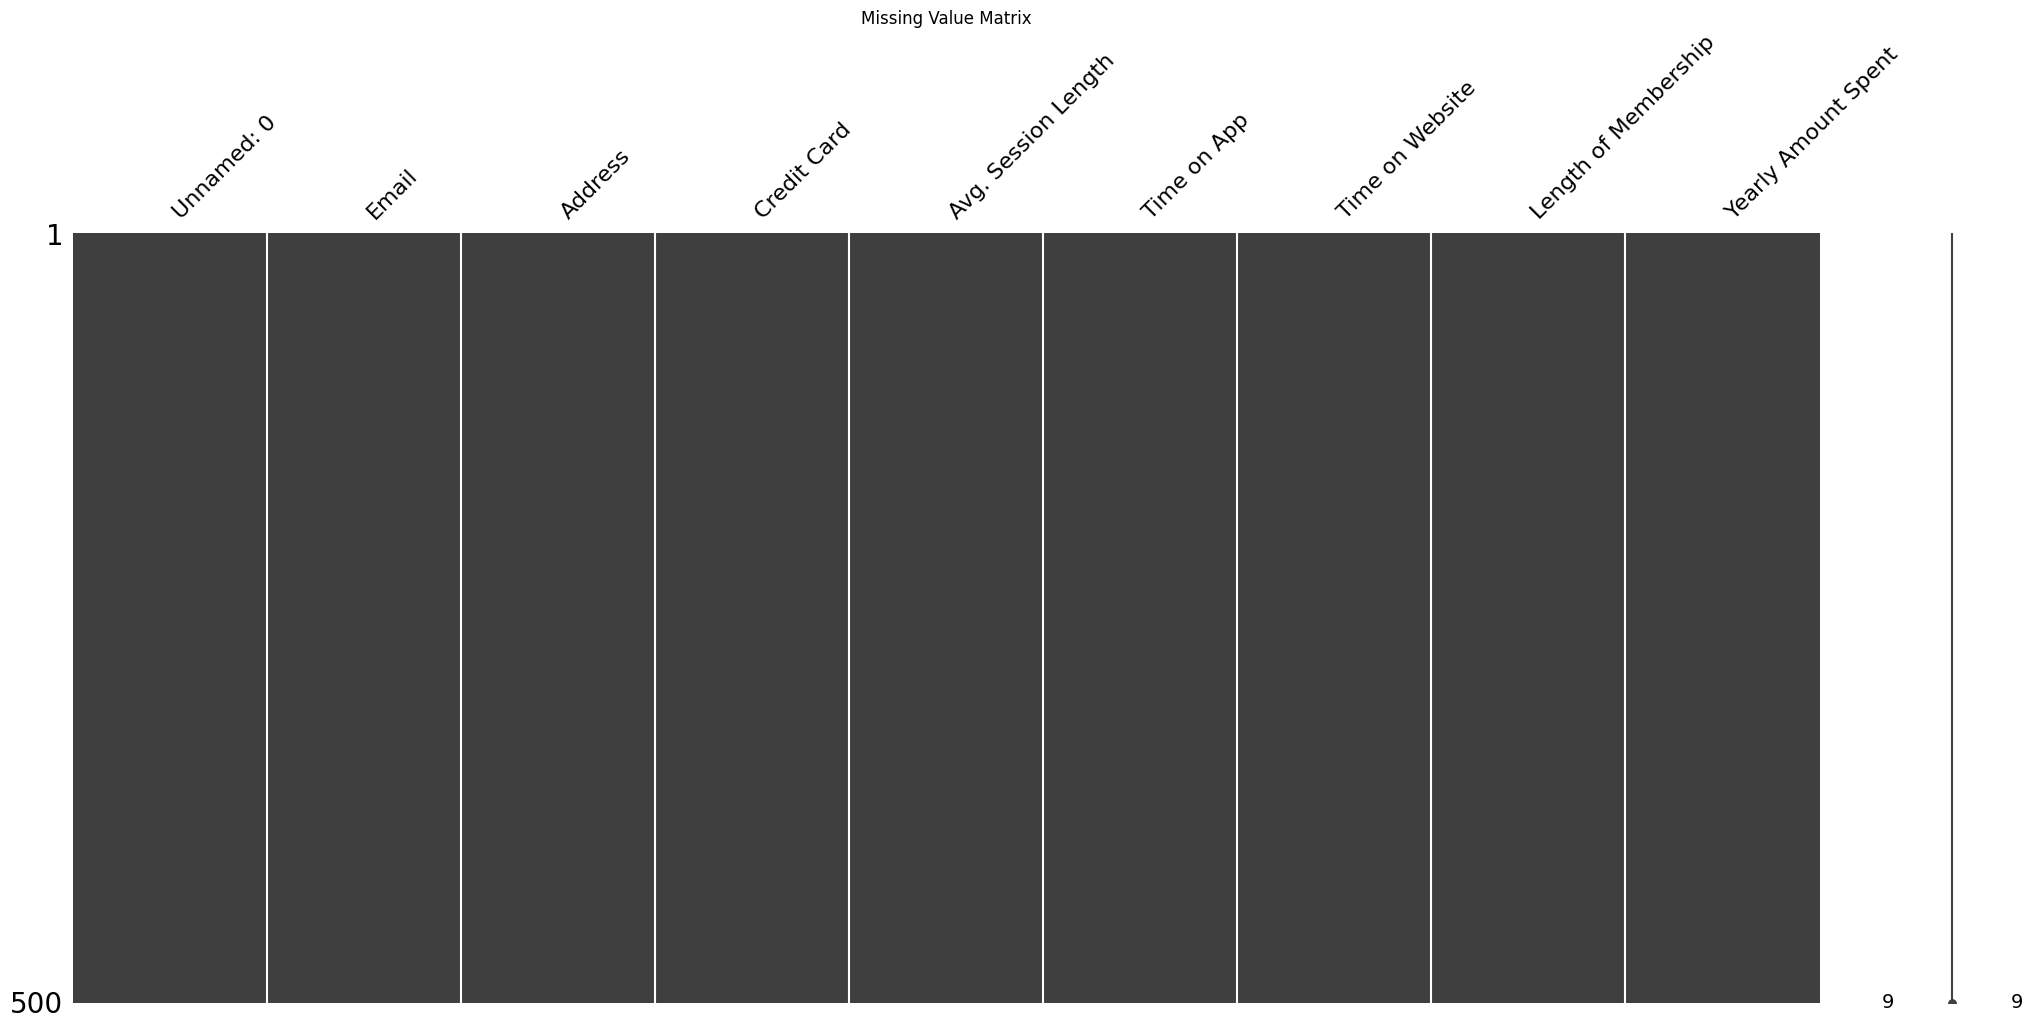

In [146]:
# white steaks in this matrix would mean missing data & fully filled = complete

msno.matrix(df)
plt.title("Missing Value Matrix")
plt.tight_layout()
plt.show()

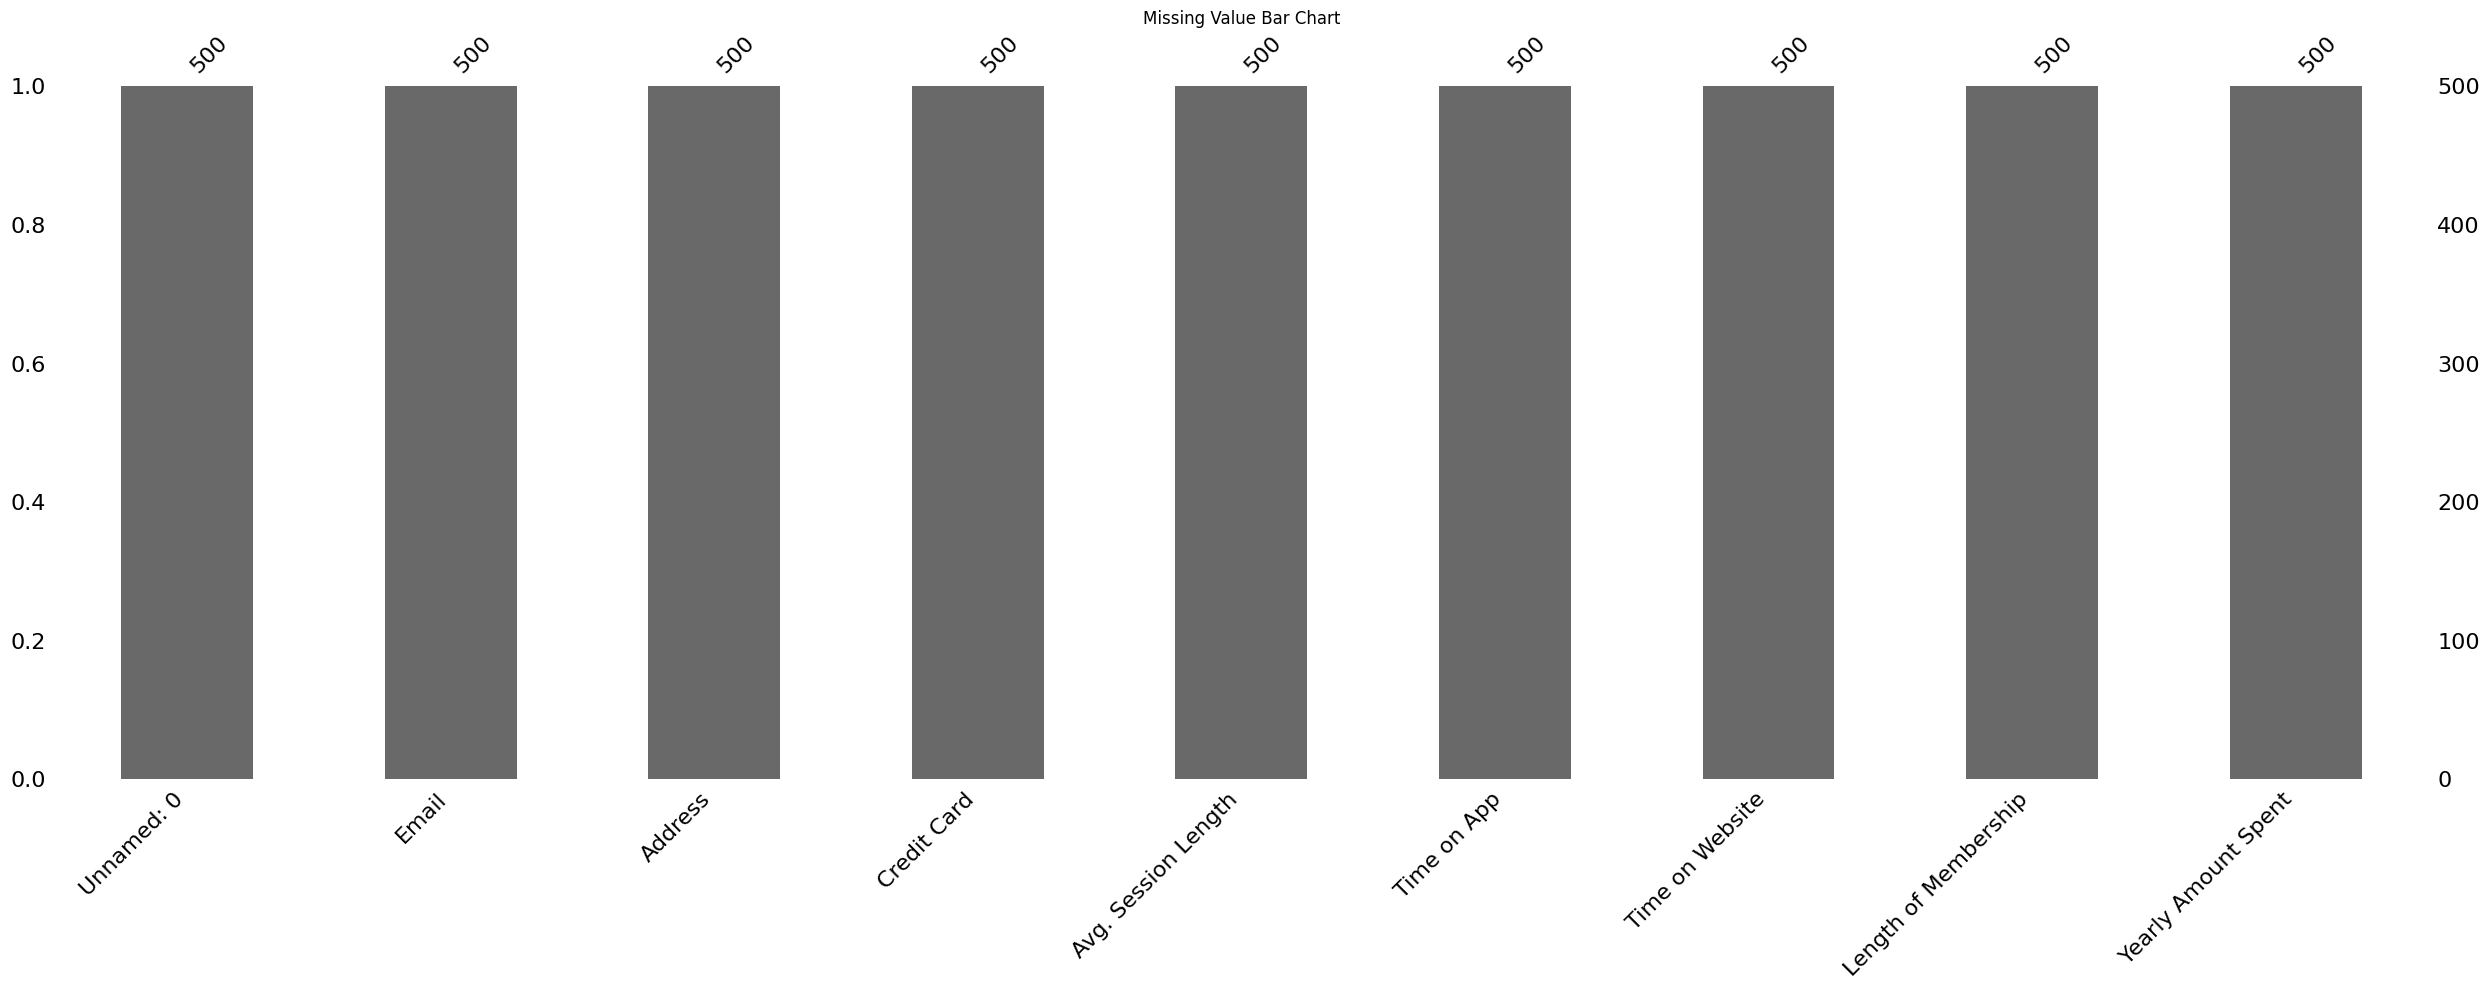

In [147]:
# Each bar reaching the top means 100% complete for that column

msno.bar(df)
plt.title("Missing Value Bar Chart")
plt.tight_layout()
plt.show()

- Observation : There are no missing values inany column of the dataset. All 500 rows are complete, so no imputation or row-dropping is necessary.

## Section 1.6 Scatter Plots (8 pts)

### Plot 1 - Yearly Amount Spent vs Time on Website (1 pt)

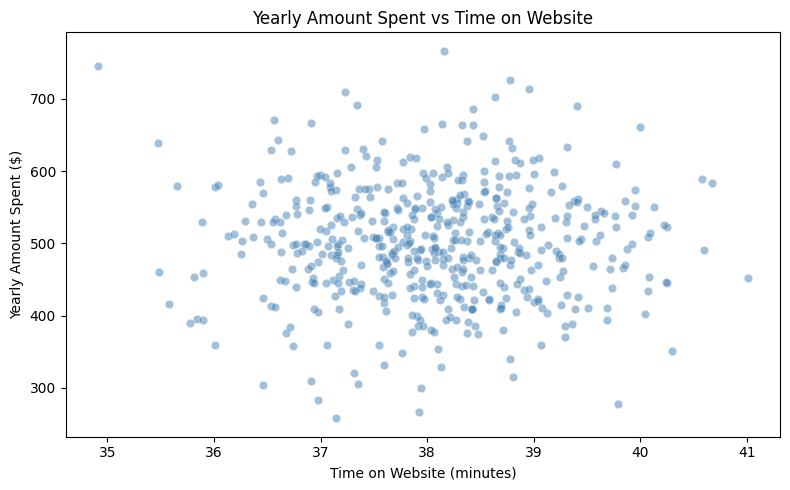

In [148]:
# alpha = 0.5 makes points semi transparent so overlapping points are visable
plt.figure(figsize=(8,5))
plt.scatter(df['Time on Website'], df['Yearly Amount Spent'], alpha=0.5, color='steelblue', edgecolors='white', linewidths=0.3)
plt.xlabel('Time on Website (minutes)')
plt.ylabel('Yearly Amount Spent ($)')
plt.title('Yearly Amount Spent vs Time on Website')
plt.tight_layout()
plt.show()

- Observation: The scatter plot shows no clear linear relationship between time spent on the website and yearly amount spent. Points are spread out broadly without any visable upward or downward trend, suggesting the website experience has little impact on revenue.

### Plot 2 - Yearly Amount Spent Vs Time on App

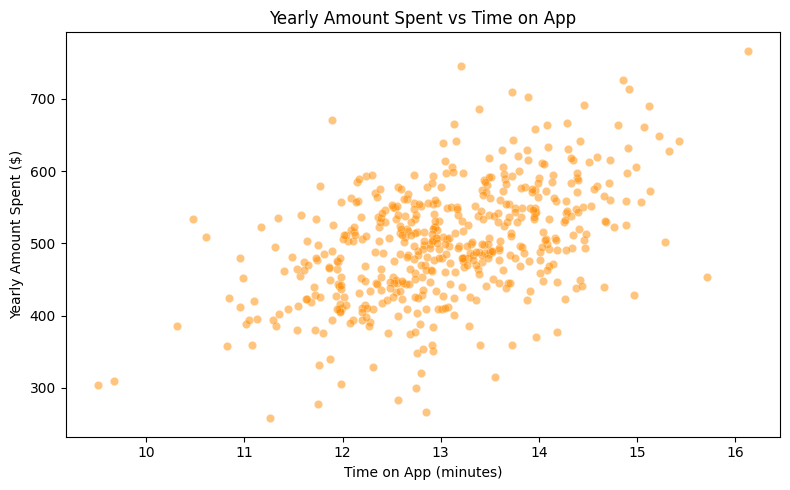

In [149]:
# looking for an upward trend meaning more app time = more spending

plt.figure(figsize=(8,5))
plt.scatter(df['Time on App'], df['Yearly Amount Spent'], alpha=0.5, color='darkorange', edgecolors='white', linewidths=0.3)
plt.xlabel('Time on App (minutes)')
plt.ylabel('Yearly Amount Spent ($)')
plt.title('Yearly Amount Spent vs Time on App')
plt.tight_layout()
plt.show()

- Observation: There is a moderate positive relationship between time on the app and yearly amount spent. As customers spend more minutes on the app, they tend to spend more money - a visable upward trend is present, confirming the app is a more effective revenue channel than the website.

### Plot 3 : Length of Membership vs Time on App

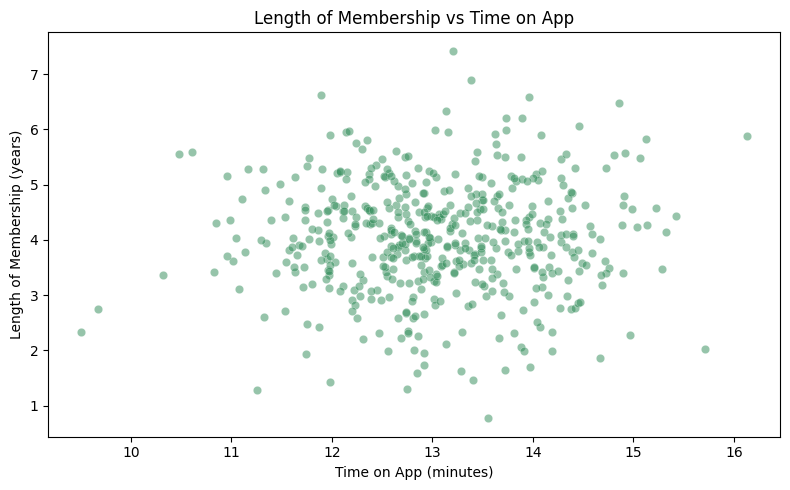

In [150]:
# checking if longer members use the app more

plt.figure(figsize=(8,5))
plt.scatter(df['Time on App'], df['Length of Membership'], alpha=0.5, color='seagreen', edgecolors='white', linewidths=0.3)
plt.xlabel('Time on App (minutes)')
plt.ylabel('Length of Membership (years)')
plt.title('Length of Membership vs Time on App')
plt.tight_layout()
plt.show()

- Observations: This scatter plot shows no strong correlation between length of membership and time on the app. The points are scattered without a clear pattern, meaning that how long an individual has been a member does not significantly predict how much time they spend on the app.

### Plot 4 - Seaborn Pairplot of all Numerical Features

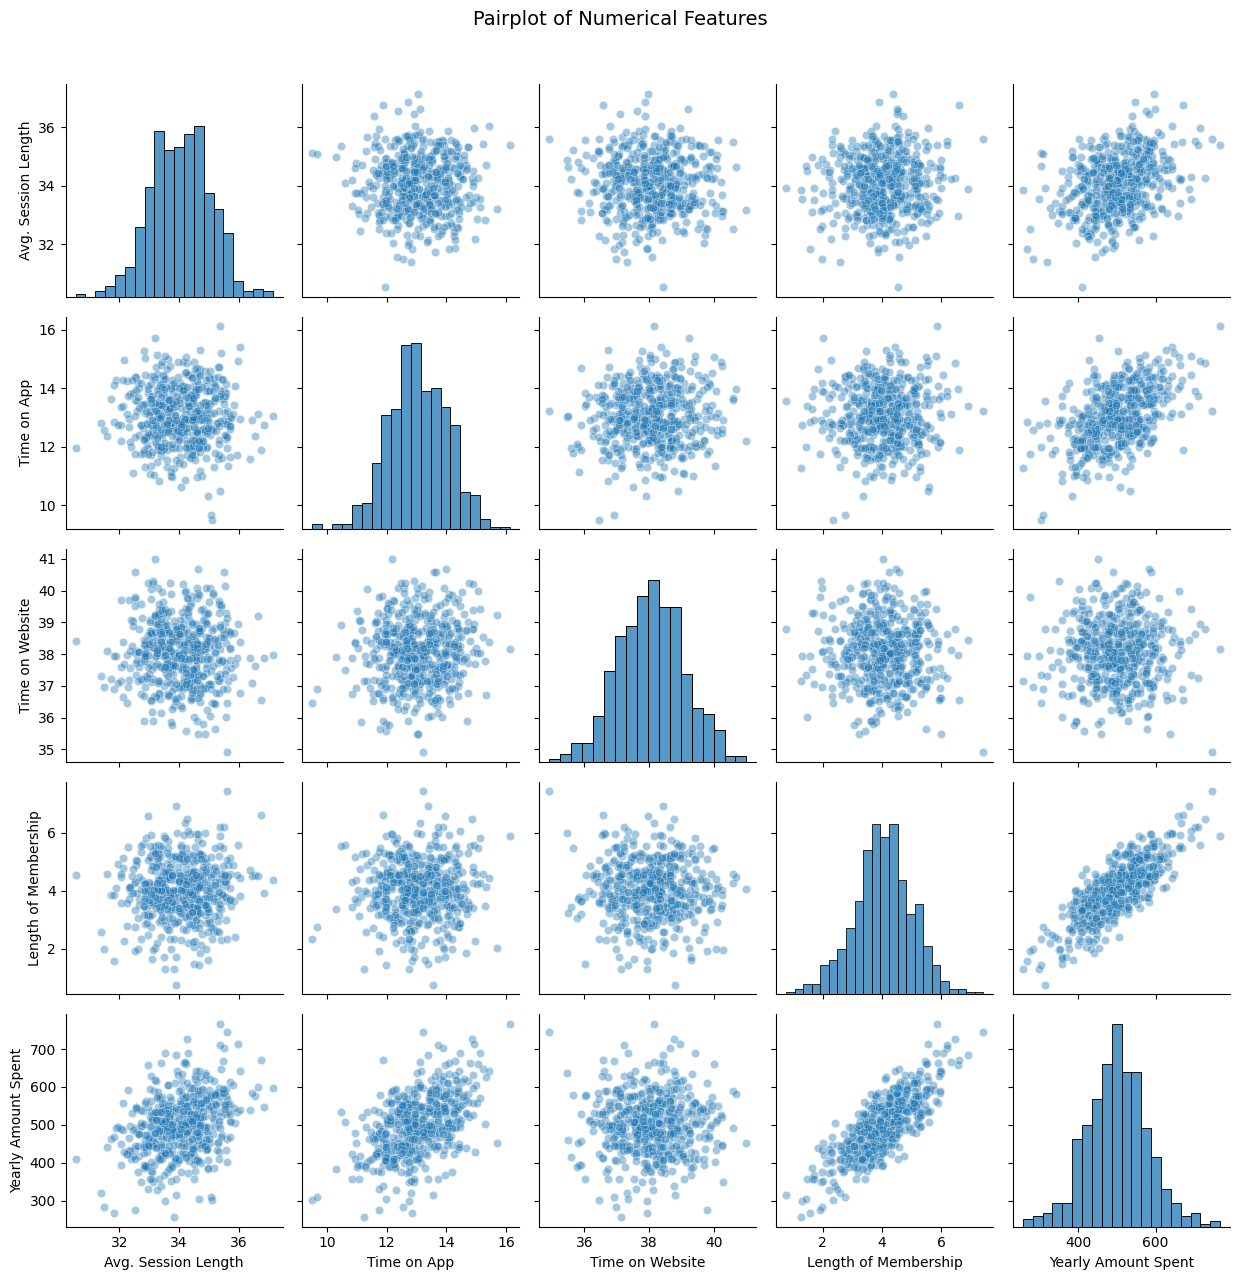

In [151]:
# pairplot shows every feature plotted against every other feature at once
# diagonal shows the distribution of each feature individually

numerical_cols = ['Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership', 'Yearly Amount Spent']

sns.pairplot(df[numerical_cols], plot_kws={'alpha': 0.4})
plt.suptitle('Pairplot of Numerical Features', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

- Observations from Pairplot: Looking at the column showing relationships with Yearly Amount Spent, it is visually clear that Length of Membership has the tightest and most linear scatter - points align closely along a disgonal, indicating the strongest correlation with yearly spending. Time on App also indicates a moderate positive trend, while Time on Website and Avg. Sessions Length show weaker and more scattered relationships.

### Plot 5 - Correlation HeatMap

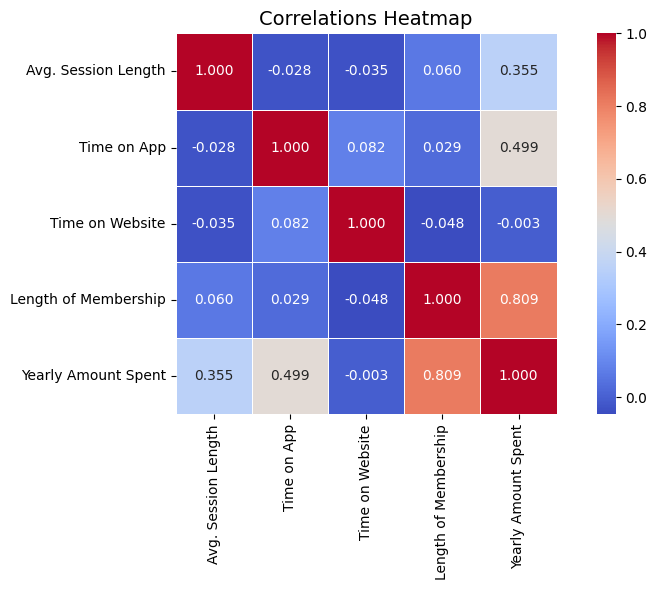

In [152]:
# correlation values range from -1 to +1
# +1 = perfect positive, 0 = no relationship, -1 = perfect negative

corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(9,6))
sns.heatmap(corr_matrix, annot=True, fmt='.3f',cmap='coolwarm', linewidths=0.5, square=True)
plt.title('Correlations Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

- Obesrvation from Heatmap 
    - Columns that should be removed : 
    Email, Address and Credit card are non numerical categorical identiiers - each value is unique from customer to customer and carries zero predictive signal for regression. The Unnamed : 0 column simply a row index and also redundant as well.
    - Most interesting column related to Yearly Amount Spent: Length of Membership has the highest correlation of +0.809 with Yearly Amount Spent, making it by far the most important and interesting predictor. Time on App follows with a moderate correlation of 0.499, while Time on Website has a near-zero correlation of -0.003, meaning that it contributes almost nothing to predicting yearly spending.

### Plot 6 - Length of Membership vs Yearly Amount Spent

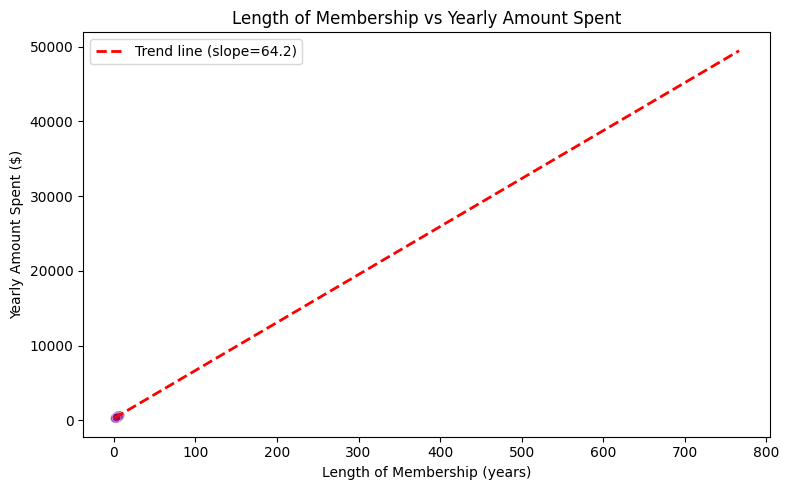

In [153]:
#

plt.figure(figsize=(8,5))
plt.scatter(df['Length of Membership'], df['Yearly Amount Spent'], alpha=0.5, color='purple', edgecolors='white', linewidths=0.3)

# Add a trend line
m, b = np.polyfit(df['Length of Membership'], df['Yearly Amount Spent'], 1)
x_line = np.linspace(df['Length of Membership'].min(), df['Yearly Amount Spent'].max(), 100)
plt.plot(x_line, m * x_line + b, color='red', lw = 2, linestyle='--', label=f'Trend line (slope={m:.1f})')

plt.xlabel('Length of Membership (years)')
plt.ylabel('Yearly Amount Spent ($)')
plt.title('Length of Membership vs Yearly Amount Spent')
plt.legend()
plt.tight_layout()
plt.show()

- Observation : This scatter plot clearly confirms the strong positive linear relationship between Length of Membership and Yearly Amount Spent. The trend line shows that for each additional year of membership, yearly spending increases substantially. Longer-tenured customers are clearly the company's most valuable revenue drivers.

## Section 2 - Feature Selection and Pre-processing (4 pts)

In [154]:
# Email, Address, and Credit Card are unique text identifiers per customer
# they carry no mathematical value for regression so we drop them
# Unnamed: 0 is just a duplicate row index — also dropped
# Time on Website stays even though correlation is low — assignment requires it
df_clean = df.drop(columns=['Unnamed: 0', 'Email', 'Address', 'Credit Card'])

print("Remaining Columns:", df_clean.columns.tolist())
print("Shape after Dropping:", df_clean.shape)
df_clean.head()

Remaining Columns: ['Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership', 'Yearly Amount Spent']
Shape after Dropping: (500, 5)


,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,35.497268,13.655651,40.577668,4.582621,588.951054
1,32.926272,12.109461,38.268959,3.164034,393.204933
2,34.000915,12.330278,38.110597,4.604543,488.547505
3,35.305557,14.717514,37.721283,3.620179,582.852344
4,34.330673,13.795189,38.536653,4.946308,600.406092


- Observation : Email, Address, and Credit Card were unique text identifiers per customer and since they're unique they do not have any correlation the the other customers thus no mathematical value for regression. similarly with the unnamed column since its acting as another row index.

## Section 3 — X/Y Split, Train/Test Split, and Scaling (8 pts)

### Section 3.1 Define X and Y, then Train/Test Split (4 pts)

In [155]:
from sklearn.model_selection import train_test_split

# x = all feature columns used to make predictions
X = df_clean.drop(columns=['Yearly Amount Spent'])

# Y = target columns we are trying to predict
y = df_clean['Yearly Amount Spent']

# 30% test, 70% train - random_state=101 makes results reproducible
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=101)

print(f"Training size   : {X_train.shape[0]} rows")
print(f"Test size   : {X_test.shape[0]} rows")

Training size   : 350 rows
Test size   : 150 rows


### Section 3.2 - Scale Features using StandardScaler (4 pts)

In [206]:
from sklearn.preprocessing import StandardScaler

# StandardScaler transforms each feature to mean=0 and std=1
# fit_transform on train — learns mean and std from training data only
# transform on test — applies same learned scale without peeking at test data
# fitting on test data too would be data leakage — model would be cheating
# y is NOT scaled because it is the raw target value we want to predict
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"Train shape: {X_train_scaled.shape}, Test shape: {X_test_scaled.shape}")

Train shape: (350, 4), Test shape: (150, 4)


- Why Scaling Matters?
    - All features are on different scales - Membership is 0-7 years while website time is 34-41 minutes. Without scaling, gradient descent would take much longer to coverage since it treats larger numbers as more important.
- Why only fit on Training Data: 
    - The Scaler Learns the mean and std from training data only. i we let it see the test data too, the model would have an unfair advantage - for example it would be like giving a student the answer before the exam aka a data leakage.

## Section 4 - Linear Regression using Sklearn (25 pts)

THis Section trains a linear regression model on our Scaled data, examines the coefficients to understand feature importance, make predictoions on the test set, and evaluates preformance using 4 metrics.

### 4.1 - Train the Model and Show Coefficients (5 pts)

In [157]:
from sklearn.linear_model import LinearRegression

# LinearRegression finds the best fit line through all data points
# by minimizing the sum of squared errors between predicted and actual values
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

# intercept = baseline prediction when all features are zero
# coef_ = how much yearly spending changes per 1 std increase in each feature
print("Intercept:", lin_reg.intercept_)
print("\nCoefficients:")
for name, coef in zip(X.columns, lin_reg.coef_):
    print(f"    {name:<25}  :  {coef:.4f}")
    

Intercept: 499.7231164913073

Coefficients:
    Avg. Session Length        :  26.0427
    Time on App                :  36.6743
    Time on Website            :  0.1850
    Length of Membership       :  60.2024


### 4.2 - Predict on Test Set and Plot Results (10 pts)

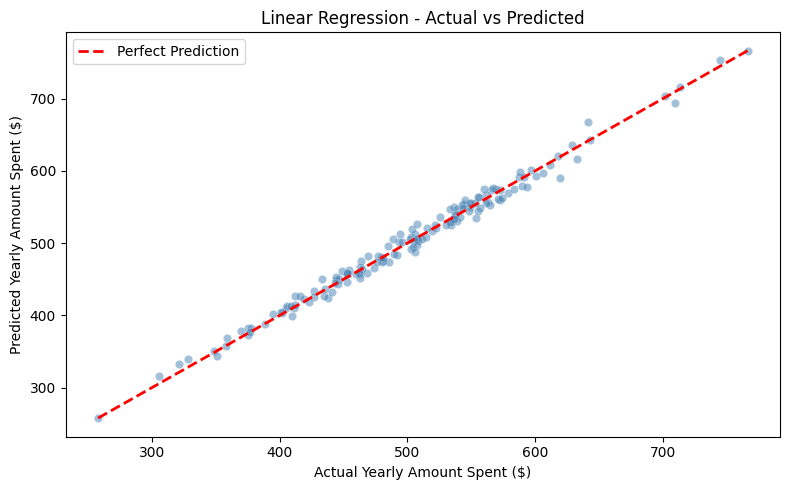

In [158]:
# use the trained model to predict yearly spending on unseen test data
y_pred_lr = lin_reg.predict(X_test_scaled)

# perfect model would show all points on the red diagonal line
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_lr, alpha=0.5, color='steelblue',edgecolors='white', linewidths=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')

plt.xlabel('Actual Yearly Amount Spent ($)')
plt.ylabel('Predicted Yearly Amount Spent ($)')
plt.title('Linear Regression - Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()

### 4.3 - Evaluation Metrics (5 pts)

In [159]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# MAE  — average absolute error, easy to interpret in dollars
# MSE  — squares the errors so large mistakes are penalized more
# RMSE — square root of MSE, back in dollar units like MAE
# R²   — percentage of variance explained, closer to 1.0 is better
mae = mean_absolute_error(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lr)

print(f"MAE     : {mae:.4f}")
print(f"MSE     : {mse:.4f}")
print(f"RMSE    : {rmse:.4f}")
print(f"R²      : {r2:.4f}")

MAE     : 7.2281
MSE     : 79.8131
RMSE    : 8.9338
R²      : 0.9890


### 4.4 Intereption:
- Metrics:
    - R² of 0.989 means the model explains 98.9% of the variance in spending which is very accurate
    - RMSE of 8.93 means productions are only off by aboiut $8.93 on a $500 average which is also very good
- Coefficients:
    - Length of Membership (61.98) is the biggest driver and since longer members spend significantly more, company should invest in loyalty programs
    - Time on App (36.67) is second meaning more app engagement = more spending. This metric proves that this company should imporve the mobile App'
    - Time on Webssite (0.185) is nearly zero indicating that website improvements will not impact revenue.
    - Avg. Session Length (26.04) suggesting that although in-store sessions still matter, it's less than membership and app

## Section 5 - Normal Equation (25 pts)

### 5.1 - Implement Normal Equation and Find Best Theta (5 pts)

In [160]:
# add a column of ones to X_train for the bias term (intercept)
# this is the x0 = 1 trick so theta_0 acts as the intercept
X_train_b = np.c_[np.ones((X_train_scaled.shape[0],1)), X_train_scaled]

# converting y_train to a numpy column vector
y_train_np = y_train.to_numpy().reshape(-1,1)

# Normal Equation: theta = (X^T X)^-1 X^T y
# linalg.inv computes the matrix inverse
# @ is matrix multiplication in numpy
theta_best = np.linalg.inv(X_train_b.T @ X_train_b) @ X_train_b.T @ y_train_np

print("Theta values from Normal Equation:")
labels = ['Intercept'] + X.columns.tolist()
for label, theta in zip(labels, theta_best.flatten()):
    print(f"    {label:<25} :  {theta:.4f}")



Theta values from Normal Equation:
    Intercept                 :  499.7231
    Avg. Session Length       :  26.0427
    Time on App               :  36.6743
    Time on Website           :  0.1850
    Length of Membership      :  60.2024


### 5.2 - Compare Theta Values to sklearn LinearRegression (5 pts)

In [161]:
# side by side comparison of Normal Equation vs sklearn LinearRegression
# they should be virtually identical since both solve the same problem
feature_labels = ['Intercept'] + X.columns.tolist()
sklearn_thetas = [lin_reg.intercept_] + list(lin_reg.coef_)

print(f"{'Feature':<25} {'Normal Eq':>12} {'sklearn LR':>12}")
print("="*52)
for label, ne_t, sk_t in zip(feature_labels, theta_best.flatten(), sklearn_thetas):
    print(f"{label:<25} {ne_t:>12.4f} {sk_t:>12.4f}")

Feature                      Normal Eq   sklearn LR
Intercept                     499.7231     499.7231
Avg. Session Length            26.0427      26.0427
Time on App                    36.6743      36.6743
Time on Website                 0.1850       0.1850
Length of Membership           60.2024      60.2024


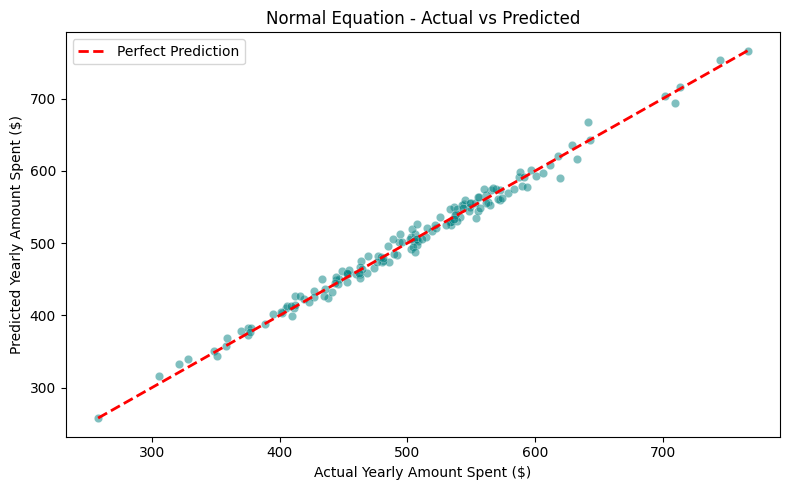

In [162]:
# add bias column to test set just like we did for training
X_test_b = np.c_[np.ones((X_test_scaled.shape[0], 1)), X_test_scaled]

# predict by multiplying test matrix by our theta values
y_pred_ne = (X_test_b @ theta_best).flatten()

# plot actual vs predicted
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_ne, alpha=0.5, color='teal', edgecolor='white', linewidths=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')


plt.xlabel('Actual Yearly Amount Spent ($)')
plt.ylabel('Predicted Yearly Amount Spent ($)')
plt.title('Normal Equation - Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()

### 5.4 - Evaluation Metrics (5 pts)

In [163]:
# same metrics as Section 4 — should be identical since Normal Equation
# and sklearn LinearRegression both find the exact same optimal solution
mae_ne = mean_absolute_error(y_test, y_pred_ne)
mse_ne = mean_squared_error(y_test, y_pred_ne)
rmse_ne = np.sqrt(mse_ne)
r2_ne = r2_score(y_test, y_pred_ne)

print(f"MAE     : {mae_ne:.4f}")
print(f"MSE     : {mse_ne:.4f}")
print(f"RMSE    : {rmse_ne:.4f}")
print(f"R²      : {r2_ne:.4f}")



MAE     : 7.2281
MSE     : 79.8131
RMSE    : 8.9338
R²      : 0.9890


### Section 5.5 Intereption
- The Normal Equation works well for small datasets but becomes very slow as the number of features grows because it has to compute a matrix becomes impossible to invert and the equation breaks down completely. It also requires loading the entire dataset into memory at once which is not practical for large datasets. Unlike gradient descent there is no way to adjust the learning rate or stop early.

## Section 6 - Batch Gradient Descent (25 pts)

Batch Gradient Descent updates theta by computing the gradient using the entire training set on every iteration. We implement it from scratch and compare the resulting theta values to the normal equation and sklearn.

### 6.1 - Implement Batch Gradient Descent (5 pts)

In [164]:
np.random.seed(42)

# hyperparameters — eta is the learning rate, controls step size
# too high = overshoots, too low = very slow convergence
eta = 0.1
n_iterations = 1000
m = X_train_b.shape[0]  # Number of training samples

# start with random theta values
theta_bgd = np.random.randn(X_train_b.shape[1], 1)

bgd_costs = []  # Store cost at each iteration to plot later

for iteration in range(n_iterations):
    # compute predictions with current theta
    y_hat = X_train_b @ theta_bgd
    # compute error between prediction and actual
    error = y_hat - y_train_np
    # gradient = direction and magnitude to adjust theta
    gradients = (2 / m) * X_train_b.T @ error
    # update theta by stepping opposite to the gradient
    theta_bgd = theta_bgd - eta * gradients
    # record cost (MSE) at this iteration
    cost = (1 / m) * np.sum(error ** 2)
    bgd_costs.append(cost)

print("Batch Gradient Descent complete!")
print("\nTheta values from BGD:")
for label, theta in zip(feature_labels, theta_bgd.flatten()):
    print(f"    {label:<25} :  {theta:.4f}")

Batch Gradient Descent complete!

Theta values from BGD:
    Intercept                 :  499.7231
    Avg. Session Length       :  26.0427
    Time on App               :  36.6743
    Time on Website           :  0.1850
    Length of Membership      :  60.2024


### 6.2 - Compare Theta Values to sklearn LinearRegression (5 pts)


In [165]:
# comparing BGD thetas to sklearn to verify they converged correctly
print(f"{'Feature': <25}   {'BGD':>12}  {'sklearn LR':>12}")
print("="*52)
for label, bgd_t, sk_t in zip(feature_labels, theta_bgd.flatten(), sklearn_thetas):
    print(f"{label:<25} {bgd_t:>12.4f} {sk_t:>12.4f}")

Feature                              BGD    sklearn LR
Intercept                     499.7231     499.7231
Avg. Session Length            26.0427      26.0427
Time on App                    36.6743      36.6743
Time on Website                 0.1850       0.1850
Length of Membership           60.2024      60.2024


### 6.3 - Cost vs Iteration Plot (5 pts)

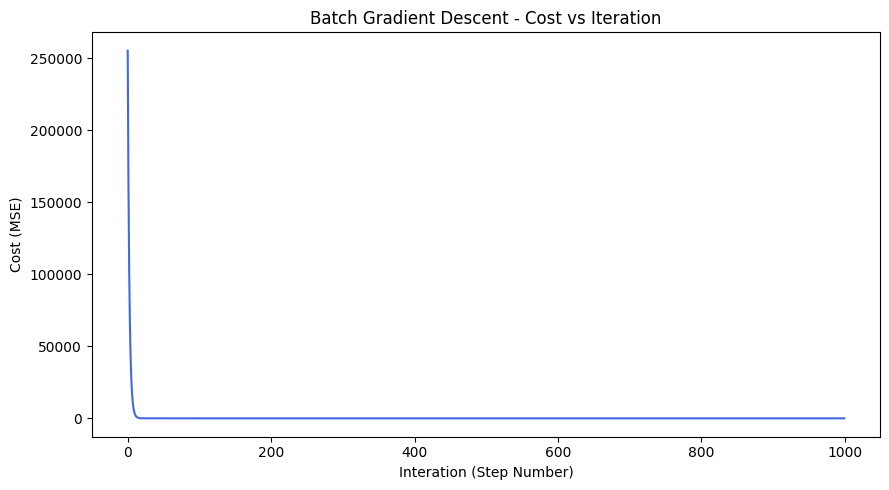

In [166]:
# cost should drop steeply at first then flatten out as it converges
# if cost never flattens out the learning rate is too high
plt.figure(figsize=(9,5))
plt.plot(range(n_iterations), bgd_costs, color='royalblue', lw=1.5)
plt.xlabel('Interation (Step Number)')
plt.ylabel('Cost (MSE)')
plt.title('Batch Gradient Descent - Cost vs Iteration')
plt.tight_layout()
plt.show()

### 6.4 - Predict on Test Set and Plot Results (5 pts)

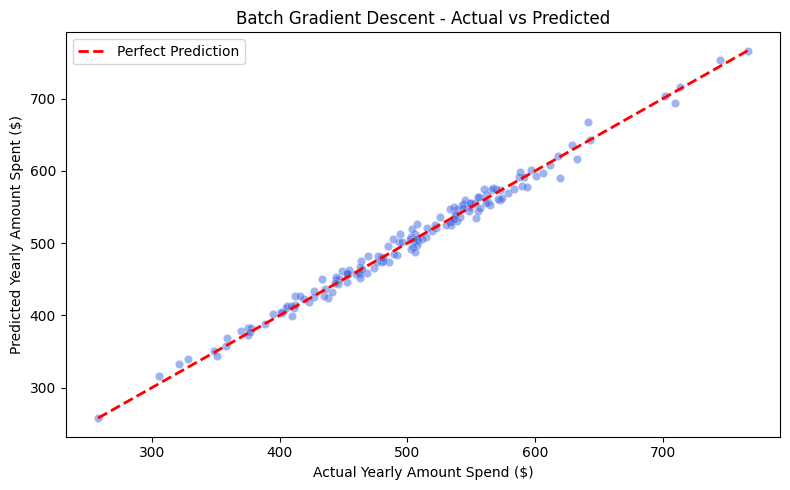

In [167]:
# predict using our BGD theta values
y_pred_bgd = (X_test_b @ theta_bgd).flatten()
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred_bgd, alpha=0.5, color='royalblue', edgecolors = 'white', linewidth = 0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Yearly Amount Spend ($)')
plt.ylabel('Predicted Yearly Amount Spent ($)')
plt.title('Batch Gradient Descent - Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()

### Section 6.5 - Evaluation Metrics (5 pts)

In [168]:
mae_bgd = mean_absolute_error(y_test, y_pred_bgd)
mse_bgd = mean_squared_error(y_test, y_pred_bgd)
rmse_bgd = np.sqrt(mse_bgd)
r2_bgd = r2_score(y_test, y_pred_bgd)

print(f"MAE     : {mae_bgd:.4f}")
print(f"MSE     : {mse_bgd:.4f}")
print(f"RMSE    : {rmse_bgd:.4f}")
print(f"R²      : {r2_bgd:.4f}")

MAE     : 7.2281
MSE     : 79.8131
RMSE    : 8.9338
R²      : 0.9890


### Question 1 - How do Derivatives help in gradient descent?
- Derivatives can tell us the slope of the cost function at any point
- If slope is positive we decrease theta, if negative we increase it
- without derivatives we would have no way to know which direction to move
### Question 2 - Benefits and limitations of Batch Gradient Descent?
- Benefit
    - Stable and smooth convergence because it uses all data every step
    - guaranteed to reach the minimum for convex functions like MSE
- Limitations
    - very slow on large datasets because it processes all data eveery iteration
    - requires enitre dataset in memory at once

## Section 7 - Stochastic Gradient Descent (25 pts)
SGD updates theta using one random training sample at a time instead of the entire dataset. It is much faster per iteration than Batch BD but produces noisier updates. A learning schedule is used to gradually reduce the learning the rate as training progresses.

### Section 7.1 - Implement SGB with learning Schedule (5 pts)

In [169]:
np.random.seed(42)

# learning schedule gradually reduces learning rate over time
# prevents overshooting as we get closer to the minimum
t0, t1 = 5,10
def learning_schedule(t):
    return t0/(t + t1)

n_epochs = 50       # one epoch = one full pass through the training data 
m_sgd = X_train_b.shape[0]
theta_sgd = np.random.randn(X_train_b.shape[1], 1)

sgd_costs = []

for epoch in range(n_epochs):
    epoch_cost = 0
    for i in range(m_sgd):
        # pick one random training instance
        random_index = np.random.randint(m_sgd)
        xi = X_train_b[random_index:random_index+1]
        yi = y_train_np[random_index:random_index+1]

        # compute gradient for just this one instance
        error = xi @ theta_sgd - yi
        gradient = 2 * xi.T @ error

        #learning rate decreases over time
        t = epoch * m_sgd + i
        eta_sgd = learning_schedule(t)

        # update theta
        theta_sgd -= eta_sgd * gradient
        epoch_cost += float(error[0][0] ** 2)
    sgd_costs.append(epoch_cost / m_sgd)

print("SGD complete!")
print("\nTheta values from SGD")
for label, theta in zip(feature_labels, theta_sgd.flatten()):
    print(f"    {label:<25}     :   {theta:.4f}")


SGD complete!

Theta values from SGD
    Intercept                     :   499.6795
    Avg. Session Length           :   25.9937
    Time on App                   :   36.4683
    Time on Website               :   -0.0073
    Length of Membership          :   60.2556


### 7.2 - Compare Theta Values to sklearn LinearRegression (5 pts)

In [170]:
# SGD thetas should be very close but not identical to sklearn
# small differences are expected due to the random/noisy nature of SGD
print(f"{'Feature':<25} {'SGD':>12} {'sklearn LR':>12}")
print("="*52)
for label, sgd_t, sk_t in zip(feature_labels, theta_sgd.flatten(), sklearn_thetas):
    print(f"{label:<25} {sgd_t:>12.4f} {sk_t:>12.4f}")

Feature                            SGD   sklearn LR
Intercept                     499.6795     499.7231
Avg. Session Length            25.9937      26.0427
Time on App                    36.4683      36.6743
Time on Website                -0.0073       0.1850
Length of Membership           60.2556      60.2024


### 7.3 - Cost vs Epoch Plot (5 pts)

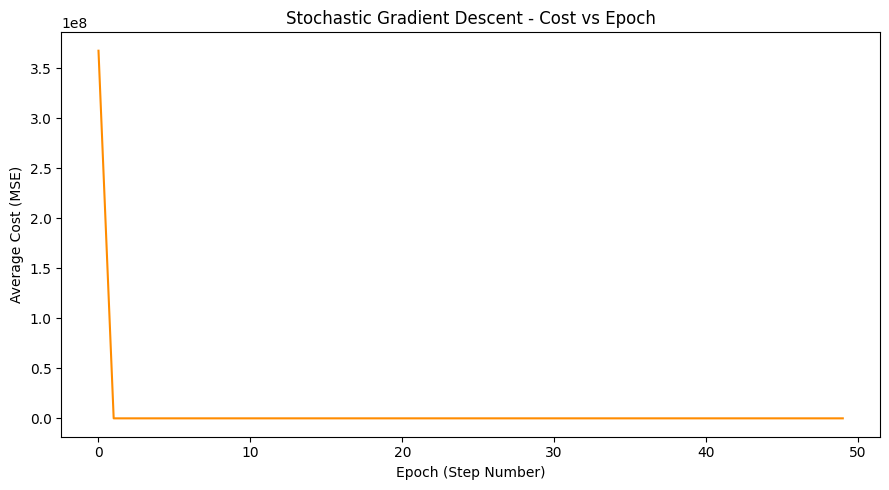

In [171]:
# SGD cost will look noisy and jumpy compared to the smooth BGD curve
# this is because each step only uses one random sample not the full dataset
plt.figure(figsize=(9,5))
plt.plot(range(n_epochs), sgd_costs, color='darkorange', lw=1.5)
plt.xlabel('Epoch (Step Number)')
plt.ylabel('Average Cost (MSE)')
plt.title('Stochastic Gradient Descent - Cost vs Epoch')
plt.tight_layout()
plt.show()

### Section 7.4 - Predict on Test Set and Plot Results (5 pts)

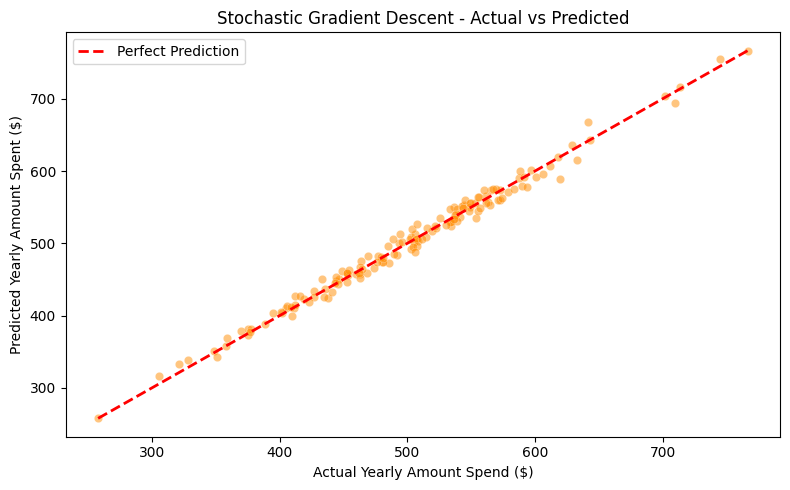

In [172]:
y_pred_sgd = (X_test_b @ theta_sgd).flatten()
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred_sgd, alpha=0.5, color='darkorange', edgecolors = 'white', linewidth = 0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Yearly Amount Spend ($)')
plt.ylabel('Predicted Yearly Amount Spent ($)')
plt.title('Stochastic Gradient Descent - Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()

### 7.5 - Evaluation Metrics (5 pts)

In [173]:
mae_sgd = mean_absolute_error(y_test, y_pred_sgd)
mse_sgd = mean_squared_error(y_test, y_pred_sgd)
rmse_sgd = np.sqrt(mse_sgd)
r2_sgd = r2_score(y_test, y_pred_sgd)

print(f"MAE     : {mae_sgd:.4f}")
print(f"MSE     : {mse_sgd:.4f}")
print(f"RMSE    : {rmse_sgd:.4f}")
print(f"R²      : {r2_sgd:.4f}")

MAE     : 7.2335
MSE     : 80.2428
RMSE    : 8.9578
R²      : 0.9889


### 7.6 - Short Question: Benefits and Limitations of SGD (5 pts)
- Benefits
    - way faster than Batch GD since only one sample is used per update
    - The randomness helps escape local minima
    - memory efficient - never needs the whole dataset at once
- Limitations
    - Cost curve is noisy and jumpy - never as smooth as BGD
    - bas learning schedule = unstable or slow training
    - Bounces around the minimum instead of settling exactly at a value}

## Section 8 - SGDRegressor from sklearn (25 pts)

sklearn's SGDRegressor is a built-in implementation of SGD. We compare 
its coefficients and performance to our manual SGD from Section 7 
and to sklearn's LinearRegression from Section 4.

### Section 8.1 - Train SGDRegressor (5 pts)

In [174]:
from sklearn.linear_model import SGDRegressor

# max_iter = max number of passes over training data
# tol = stops early if improvement is less than this amount
# eta0 = starting learning rate
# learning_rate = invscaling means it decreases over time like our schedule
sgd_reg = SGDRegressor(max_iter=1000, tol=1e-4, eta0=0.01, learning_rate='invscaling', random_state=42)
sgd_reg.fit(X_train_scaled, y_train)
print("SGDRegressor trained successfully!")

SGDRegressor trained successfully!


### 8.2 - Compare Theta Values to sklearn LinearRegression (5 pts)

In [175]:
# intercept_ and coef_ give us the learned theta values
sgd_reg_thetas = [sgd_reg.intercept_[0]] + list(sgd_reg.coef_)

print(f"{'Feature':<25} {'SGDRegressor':>12} {'sklearn LR':>12}")
print("="*52)
for label, sgd_t, sk_t in zip(feature_labels, sgd_reg_thetas, sklearn_thetas):
    print(f"{label:<25} {sgd_t:>10.4f} {sk_t:>10.4f}")

Feature                   SGDRegressor   sklearn LR
Intercept                   499.7131   499.7231
Avg. Session Length          26.0451    26.0427
Time on App                  36.6774    36.6743
Time on Website               0.1895     0.1850
Length of Membership         60.1876    60.2024


### 8.3 - Predict on Test Set and Plot Results (10 pts)

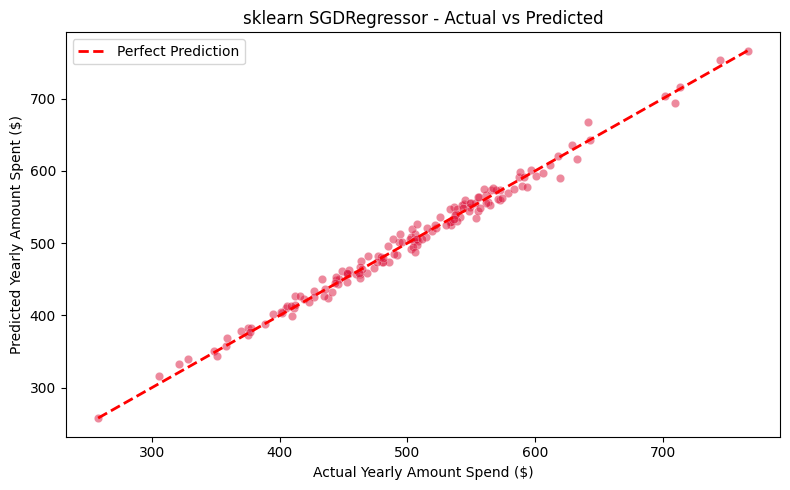

In [176]:
# SGDRegressor uses the scaled test set directly unlike our manual version
y_pred_sgdreg = sgd_reg.predict(X_test_scaled)
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred_sgdreg, alpha=0.5, color='crimson', edgecolors = 'white', linewidth = 0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Yearly Amount Spend ($)')
plt.ylabel('Predicted Yearly Amount Spent ($)')
plt.title('sklearn SGDRegressor - Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()

### Section 8.4 - Evaluation Metrics (5 pts)

In [177]:
mae_sgdreg = mean_absolute_error(y_test, y_pred_sgdreg)
mse_sgdreg = mean_squared_error(y_test, y_pred_sgdreg)
rmse_sgdreg = np.sqrt(mse_sgdreg)
r2_sgdreg = r2_score(y_test, y_pred_sgdreg)

print(f"MAE     : {mae_sgdreg:.4f}")
print(f"MSE     : {mse_sgdreg:.4f}")
print(f"RMSE    : {rmse_sgdreg:.4f}")
print(f"R²      : {r2_sgdreg:.4f}")

MAE     : 7.2289
MSE     : 79.8191
RMSE    : 8.9342
R²      : 0.9890


### Section 8.5 - Interpertation
- The SGDRegressor theta values are very close to sklearn linearRegression but not identical because SGD introduces randomness in each update
- the metrics are nearly identical to all previous methods (RMSE around 8.93 and R² of
0.989) confirming that all four approaches essentially find the same solution
- Sklearn's SGDRegressor is the most practical option since it handles the learning schedule and stopping conditions automatically without writing the loop from scratch

## Section 9 - Mini-Batch Gradient Descent (3 pts)

- Mini Batch Gradient Descent is a compromise between Batch GD and SGD. Instead of computing the gradient on the entire dataset like Batch GD or on a single sample like SGD, Mini Batch Gradient Descent splits the data into small batches ( usually 32 or 64 samples ) and updates theta once every batch.
- This makes it faster than Batch GD since it doesn't need all the data at once
    - More stable that SGD since each update is based on more than one sample. 
- It is the most widely used method in practice, especially in deep learning.

## Section 10 - Polynomial Regression Degree=2 (10 pts)

Polynomial regression adds squared and interaction terms to the features
allowing the model to capture non-linear relationships. We use degree=2
and compare performance to the linear model from Section 4.

### Section 10.1 - Create Polynomial Features (2 pts)

In [178]:
from sklearn.preprocessing import PolynomialFeatures

# degree=2 creates all squared terms and interaction terms between features
# include_bias=False because StandardScaler will handle the intercept
poly2 = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly2   = poly2.fit_transform(X_train_scaled)
X_test_poly2    = poly2.transform(X_test_scaled)

print(f"Original feature count  : {X_train_scaled.shape[1]}")
print(f"Poly degree=2 features  : {X_test_poly2.shape[1]}")

Original feature count  : 4
Poly degree=2 features  : 14


### 10.2 - Train Linear Regression on Poly=2 Features (3 pts)

In [179]:
# we still use LinearRegression — polynomial features are just transformed inputs
# the model itself is still linear in terms of the new features
lin_reg_poly2 = LinearRegression()
lin_reg_poly2.fit(X_train_poly2, y_train)
print("Polynomial degree=2 model trained!")

Polynomial degree=2 model trained!


### 10.3 - Predict and Plot Results (3 pts)

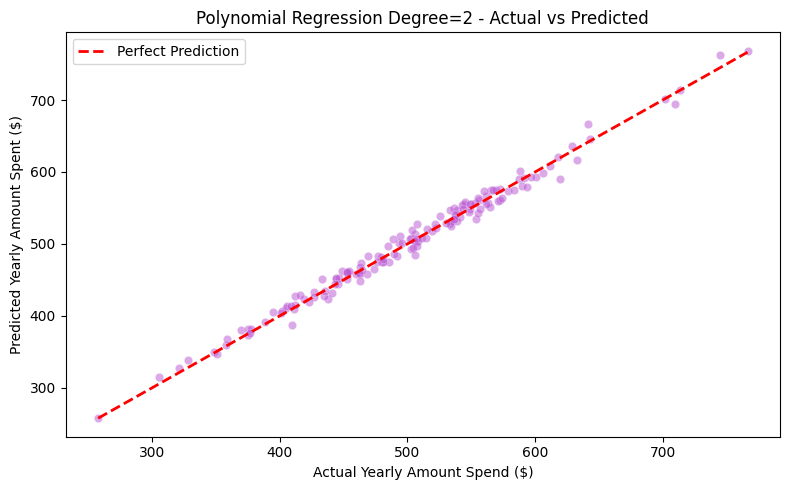

In [180]:

y_pred_poly2 = lin_reg_poly2.predict(X_test_poly2)
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred_poly2, alpha=0.5, color='mediumorchid', edgecolors = 'white', linewidth = 0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Yearly Amount Spend ($)')
plt.ylabel('Predicted Yearly Amount Spent ($)')
plt.title('Polynomial Regression Degree=2 - Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()

### Section 10.4 - Evaluation Metrics (2 pts)


In [181]:
mae_poly2 = mean_absolute_error(y_test, y_pred_poly2)
mse_poly2 = mean_squared_error(y_test, y_pred_poly2)
rmse_poly2 = np.sqrt(mse_poly2)
r2_poly2 = r2_score(y_test, y_pred_poly2)

print(f"MAE     : {mae_poly2:.4f}")
print(f"MSE     : {mse_poly2:.4f}")
print(f"RMSE    : {rmse_poly2:.4f}")
print(f"R²      : {r2_poly2:.4f}")

print("\n--- Comparsion: Linear vs Poly=2 ---")
print(f"Linear R²   : {r2:.4f}          RMSE : {rmse:.4f}")
print(f"Poly R²     : {r2_poly2:.4f}    RMSE : {rmse_poly2:.4f}")

MAE     : 7.4322
MSE     : 85.3475
RMSE    : 9.2384
R²      : 0.9882

--- Comparsion: Linear vs Poly=2 ---
Linear R²   : 0.9890          RMSE : 8.9338
Poly R²     : 0.9882    RMSE : 9.2384


- Observation:
    - Adding degree=2 polynomial features did not improve the model - the RMSE increased from 8.93 to 9.24 and R² dropped slightly from 0.989 to 0.988. This meaning the relationship in this dataset is already well captured by a linear model and adding complexioty only introduced noise

## Section 11 - Polynomial Regression Degree=3 (5 pts)

Degree=3 adds cubic terms on top of the squared and interaction terms 
from degree=2. We save this dataset as our poly3 data since sections 
14-17 all use it for regularization.

### Section 11.1 - Create Polynomial Features and Train Model (3 pts)

In [182]:
# degree=3 creates even more complex feature combinations
# we save these as poly3 variables since regularization sections 14-17 reuse them
poly3 = PolynomialFeatures(degree=3, include_bias=False)

X_train_poly3   = poly3.fit_transform(X_train_scaled)
X_test_poly3    = poly3.transform(X_test_scaled)

lin_reg_poly3 = LinearRegression()
lin_reg_poly3.fit(X_train_poly3, y_train)

print(f"Original feature        : {X_train_scaled.shape[1]}")
print(f"Poly degree=2           : {X_test_poly3.shape[1]}")
print("Degree=3 model trained!")


Original feature        : 4
Poly degree=2           : 34
Degree=3 model trained!


### 11.2 - Predict, Plot and Evaluate (2 pts)

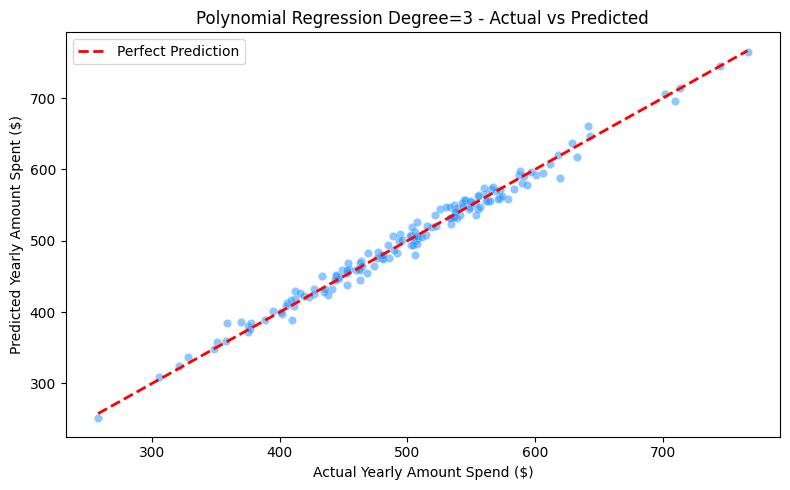

In [183]:

y_pred_poly3 = lin_reg_poly3.predict(X_test_poly3)
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred_poly3, alpha=0.5, color='dodgerblue', edgecolors = 'white', linewidth = 0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Yearly Amount Spend ($)')
plt.ylabel('Predicted Yearly Amount Spent ($)')
plt.title('Polynomial Regression Degree=3 - Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()

In [184]:
mae_poly3 = mean_absolute_error(y_test, y_pred_poly3)
mse_poly3 = mean_squared_error(y_test, y_pred_poly3)
rmse_poly3 = np.sqrt(mse_poly3)
r2_poly3 = r2_score(y_test, y_pred_poly3)

print(f"MAE     : {mae_poly3:.4f}")
print(f"MSE     : {mse_poly3:.4f}")
print(f"RMSE    : {rmse_poly3:.4f}")
print(f"R²      : {r2_poly3:.4f}")

print("\n--- Comparsion: Linear vs Poly=2 vs Poly=3 ---")
print(f"Linear R²   : {r2:.4f}          RMSE : {rmse:.4f}")
print(f"Poly R²     : {r2_poly2:.4f}    RMSE : {rmse_poly2:.4f}")
print(f"Poly R²     : {r2_poly3:.4f}    RMSE : {rmse_poly3:.4f}")

MAE     : 7.6958
MSE     : 94.9689
RMSE    : 9.7452
R²      : 0.9869

--- Comparsion: Linear vs Poly=2 vs Poly=3 ---
Linear R²   : 0.9890          RMSE : 8.9338
Poly R²     : 0.9882    RMSE : 9.2384
Poly R²     : 0.9869    RMSE : 9.7452


## Section 12 - Learning Curves (7 pts)

Learning curves show how training and validation error change as we add 
more training data. A large gap between the two curves means overfitting.
We compare LinearRegression vs Polynomial degree=5 to visualize this.

### 12.1 - Learning Curve for Linear Regression (3 pts)

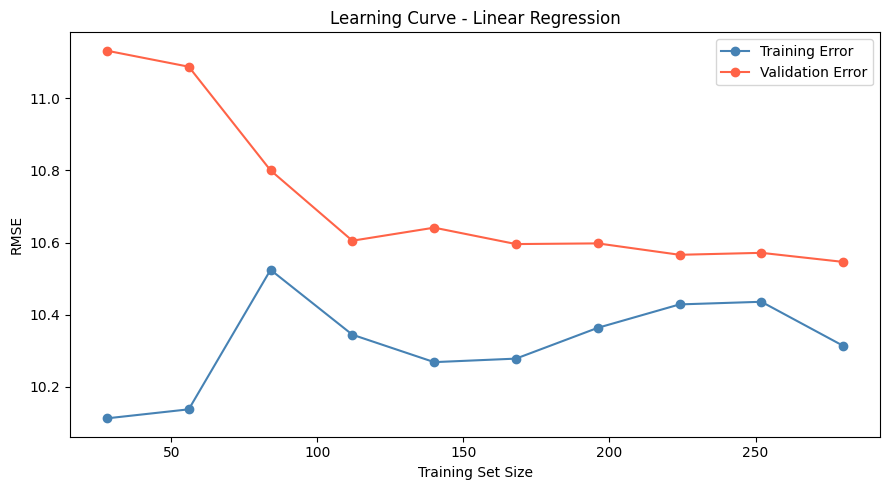

In [185]:
from sklearn.model_selection import learning_curve

# learning_curve trains the model on increasing subsets of training data
# cv=5 means 5-fold cross validation at each training size
train_sizes, train_scores_lr, val_scores_lr = learning_curve(LinearRegression(), X_train_scaled, y_train, train_sizes=np.linspace(0.1, 1.0, 10), scoring='neg_mean_squared_error', cv=5)

# scores are negative MSE so we negate and take sqrt for RMSE
train_rmse_lr = np.sqrt(-train_scores_lr.mean(axis=1))
val_rmse_lr = np.sqrt(-val_scores_lr.mean(axis=1))

plt.figure(figsize=(9,5))
plt.plot(train_sizes, train_rmse_lr, 'o-', color='steelblue', label='Training Error')
plt.plot(train_sizes, val_rmse_lr, 'o-', color='tomato', label='Validation Error')
plt.xlabel('Training Set Size')
plt.ylabel('RMSE')
plt.title('Learning Curve - Linear Regression')
plt.legend()
plt.tight_layout()
plt.show()

- Observations:
    - The training and validation error curves converge closely together as more data is added, meaning the linear model is not overfitting. Both errors stabilize at a low RMSE which confirms the linear model generalizes well to unseen data.

### 12.2 - Learning Curve for Polynomial Degree=5 (4 pts)

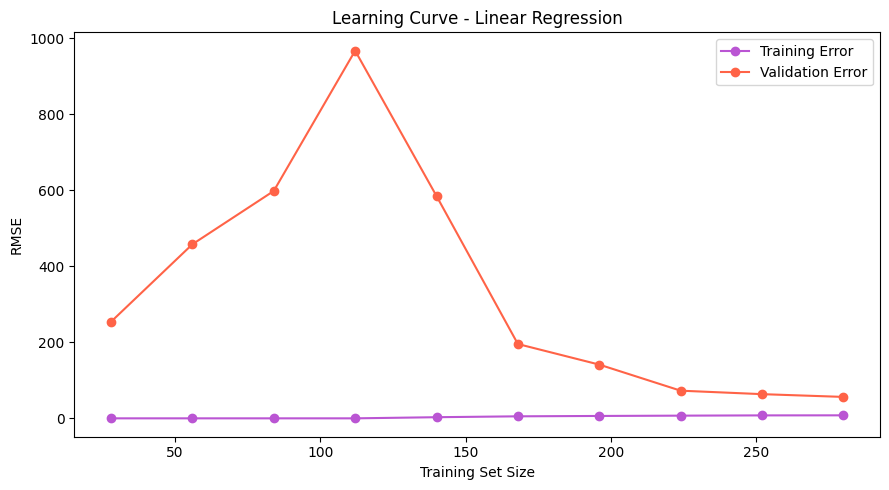

In [186]:
from sklearn.pipeline import Pipeline

# Pipeline chains PolynomialFeatures and LinearRegression together
# this lets learning_curve handle the transformation automatically
poly5_pipeline = Pipeline([('poly', PolynomialFeatures(degree=5, include_bias=False)),('lin_reg', LinearRegression())])

train_sizes, train_scores_p5, val_scores_p5 = learning_curve(poly5_pipeline, X_train_scaled, y_train, train_sizes=np.linspace(0.1, 1.0, 10), scoring='neg_mean_squared_error', cv=5)

# scores are negative MSE so we negate and take sqrt for RMSE
train_rmse_p5 = np.sqrt(-train_scores_p5.mean(axis=1))
val_rmse_p5 = np.sqrt(-val_scores_p5.mean(axis=1))

plt.figure(figsize=(9,5))
plt.plot(train_sizes, train_rmse_p5, 'o-', color='mediumorchid', label='Training Error')
plt.plot(train_sizes, val_rmse_p5, 'o-', color='tomato', label='Validation Error')
plt.xlabel('Training Set Size')
plt.ylabel('RMSE')
plt.title('Learning Curve - Linear Regression')
plt.legend()
plt.tight_layout()
plt.show()

- Observations:
    The degree=5 polynomial shows a large gap between training error and validation error, which is a clear sign of overfitting. The model memorizes the training data too closely and fails to generalize, unlike the linear model where both curves converged. This confirms that higher degree polynomials are not appropriate for this dataset.

## Section 13 - Regularization (3 pts)

Regurization is a technique to prevent overfitting by adding a penalty to the cost function that discourages large coefficient values. Ridge regression shrinks all coefficients toward zero but keeps every feature in the model. Lasso goes further and can eliminate features ocompletely by setting their coefficients to exactly zero, which makes it useful for feature selection.

## Section 14 - Ridge Regression on Poly=3 Data (8 pts)

Ridge regression adds an L2 penalty to the cost function that shrinks 
all coefficients toward zero without removing any features. We apply it 
to the poly=3 dataset from Section 11 to control overfitting.

### 14.1 - Train Ridge Regression (3 pts)

In [187]:
from sklearn.linear_model import Ridge

# alpha controls the strength of the penalty
# higher alpha = more shrinkage = simpler model
# alpha=1 is a reasonable default starting point
ridge_reg = Ridge(alpha=1, solver='cholesky')
ridge_reg.fit(X_train_poly3, y_train)
print("Ridge Regression trained!")
print("Intercept:", ridge_reg.intercept_)


Ridge Regression trained!
Intercept: 499.66172751422386


### 14.2 - Predict and Plot Results (3 pts)

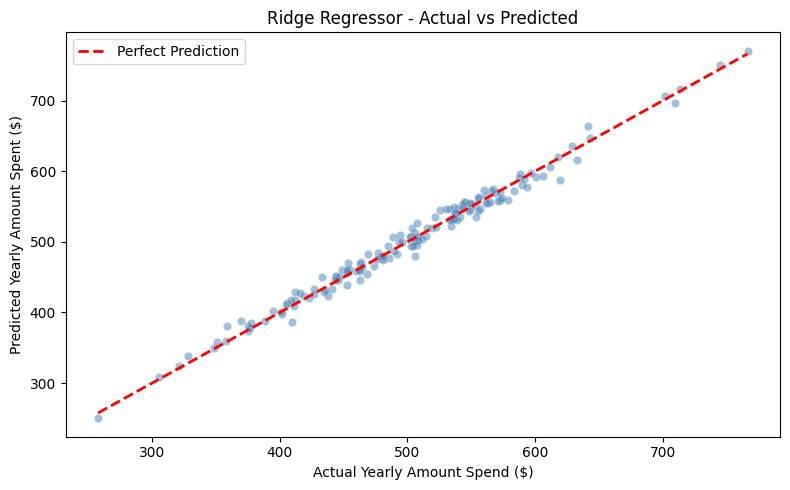

In [188]:

y_pred_ridge = ridge_reg.predict(X_test_poly3)
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred_ridge, alpha=0.5, color='steelblue', edgecolors = 'white', linewidth = 0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Yearly Amount Spend ($)')
plt.ylabel('Predicted Yearly Amount Spent ($)')
plt.title('Ridge Regressor - Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()

### Section 14.3 - Evaluation Metrics (2 pts)


In [189]:
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f"MAE     : {mae_ridge:.4f}")
print(f"MSE     : {mse_ridge:.4f}")
print(f"RMSE    : {rmse_ridge:.4f}")
print(f"R²      : {r2_ridge:.4f}")

print("\n--- Comparsion: Poly=3 vs Ridge---")
print(f"Poly R²       : {r2_poly3:.4f}    RMSE : {rmse_poly3:.4f}")
print(f"Ridge R²      : {r2_ridge:.4f}    RMSE : {rmse_ridge:.4f}")

MAE     : 7.8470
MSE     : 97.4578
RMSE    : 9.8721
R²      : 0.9866

--- Comparsion: Poly=3 vs Ridge---
Poly R²       : 0.9869    RMSE : 9.7452
Ridge R²      : 0.9866    RMSE : 9.8721


### Section 14.4 - Interpertation
- Ridge didn't improve preformance here because the data isn't actually overfitting badly - the polynomial features just aren't a good fit for this dataset regardless. Ridge shrinks coefficients but can't fix a model that's already underfitting

## Section 15 - SGDRegressor for Ridge on Poly=3 Data (8 pts)

SGDRegressor can replicate Ridge regression by setting the penalty 
parameter to l2. We compare the results to Section 14 to verify 
both approaches find the same solution.

### 15.1 - Train SGDRegressor with L2 Penalty (3 pts)

In [190]:
from sklearn.preprocessing import StandardScaler
# polynomial features need rescaling because squared/cubic terms
# have much larger magnitudes - SGD is very sensitive to feature scale

scaler_poly3 = StandardScaler()
X_train_poly3_scaled = scaler_poly3.fit_transform(X_train_poly3)
X_test_poly3_scaled = scaler_poly3.transform(X_test_poly3)

# penalty='l2' makes SGDRegressor equivalent to Ridge regression
# alpha controls the regularization strength — same as Ridge alpha
sgd_reg_ridge = SGDRegressor(penalty='l2', max_iter=10000, tol=1e-5, eta0=0.01, random_state=42)

sgd_reg_ridge.fit(X_train_poly3_scaled, y_train)
print("SGDRegressor L2 trained!")
print("Intercept:", sgd_reg_ridge.intercept_)

SGDRegressor L2 trained!
Intercept: [499.75045022]


### Section 15.2 - Predict and Plot Results (3 pts)

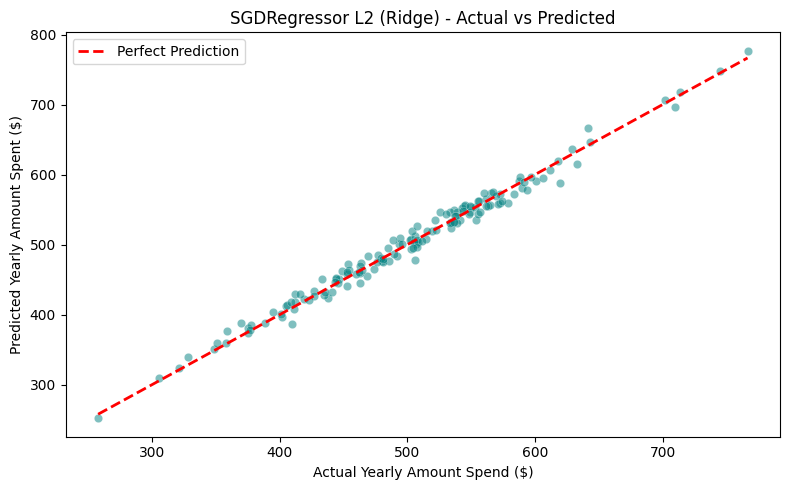

In [205]:
# predict on test set using scaled features
# compute error metrics to evaluate model performance
y_pred_sgd_ridge = sgd_reg_ridge.predict(X_test_poly3_scaled)

plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred_sgd_ridge, alpha=0.5, color='teal', edgecolors = 'white', linewidth = 0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Yearly Amount Spend ($)')
plt.ylabel('Predicted Yearly Amount Spent ($)')
plt.title('SGDRegressor L2 (Ridge) - Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()

### 15.3 - Evaluation Metrics (2 pts)

In [192]:
mae_sgd_ridge = mean_absolute_error(y_test, y_pred_sgd_ridge)
mse_sgd_ridge = mean_squared_error(y_test, y_pred_sgd_ridge)
rmse_sgd_ridge = np.sqrt(mse_sgd_ridge)
r2_sgd_ridge = r2_score(y_test, y_pred_sgd_ridge)

print(f"MAE     : {mae_sgd_ridge:.4f}")
print(f"MSE     : {mse_sgd_ridge:.4f}")
print(f"RMSE    : {rmse_sgd_ridge:.4f}")
print(f"R²      : {r2_sgd_ridge:.4f}")

print("\n--- Comparsion: Ridge vs SGD Ridge---")
print(f"Ridge R²       : {r2_ridge:.4f}     RMSE : {rmse_ridge:.4f}")
print(f"SGD Ridge R²   : {r2_sgd_ridge:.4f}     RMSE : {rmse_sgd_ridge:.4f}")

MAE     : 7.9560
MSE     : 99.6062
RMSE    : 9.9803
R²      : 0.9863

--- Comparsion: Ridge vs SGD Ridge---
Ridge R²       : 0.9866     RMSE : 9.8721
SGD Ridge R²   : 0.9863     RMSE : 9.9803


# Observations:
- SGDRegressor with L2 penalty replicates Ridge regression through gradient rather than a closed-form solution. The RMSE of 9.98 is slightly worse than Ridge at 9.87, which is expected since SGD introduces randomness and may not converge to the exact same solution

## Section 16 - Lasso on poly3 Data

### Section 16.1 - Train Lasso

In [202]:
from sklearn.linear_model import Lasso

lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(X_train_poly3, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


### Section 16.2 - Predictions + Scatter Plot

/var/folders/p6/yq_zh5cj0ws8g912gdv6g5740000gn/T/ipykernel_50964/1912137738.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


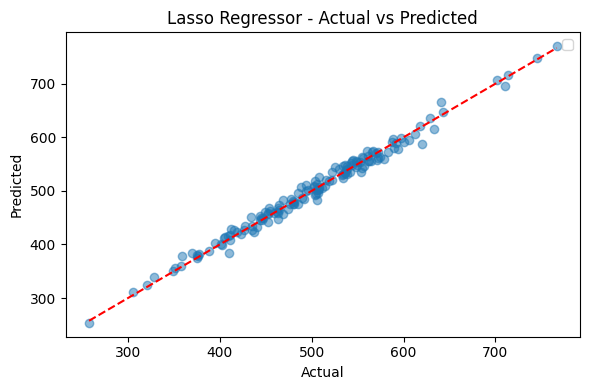

In [204]:
# predict on test set using scaled features
# compute error metrics to evaluate model performance
y_pred_lasso = lasso_reg.predict(X_test_poly3)
plt.figure(figsize=(6,4))

plt.scatter(y_test, y_pred_lasso, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') 
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Lasso Regressor - Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()

### Section 16.3 - Metrics

In [195]:
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print(f"MAE     : {mae_lasso:.4f}")
print(f"MSE     : {mse_lasso:.4f}")
print(f"RMSE    : {rmse_lasso:.4f}")
print(f"R²      : {r2_lasso:.4f}")

MAE     : 7.6828
MSE     : 93.1991
RMSE    : 9.6540
R²      : 0.9872


### Section 16.4 - How many feature went to zero

In [196]:
zero_coefs = np.sum(lasso_reg.coef_ == 0)
print(f"Coefficients set to zero by Lasso: {zero_coefs} out of {len(lasso_reg.coef_)}")

Coefficients set to zero by Lasso: 3 out of 34


### Section 16.5 - Observations
- Observation : Lasso used L1 regularization which set 3 out of 34 polynomial coefficients completely to zero, performing automatic feature selection. With an RMSE of 9.65 it performed slightly better thn Ridge (9.87), suggesting those 3 features were genuinely adding noise rather than signal.,

## Section 17 - ElasticNet on poly3 Data (10 pts)

### Section 17.1 Train ElasticNet

In [197]:
from sklearn.linear_model import ElasticNet

# alpha controls overall regularization strength
# l1_ratio=0.5 means equal mix of Lasso (L1) and Ridge (L2)

elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic_net.fit(X_train_poly3, y_train)
print("ElasticNet trained!")

ElasticNet trained!


### Section 17.2 Predictions + Scatter Plot

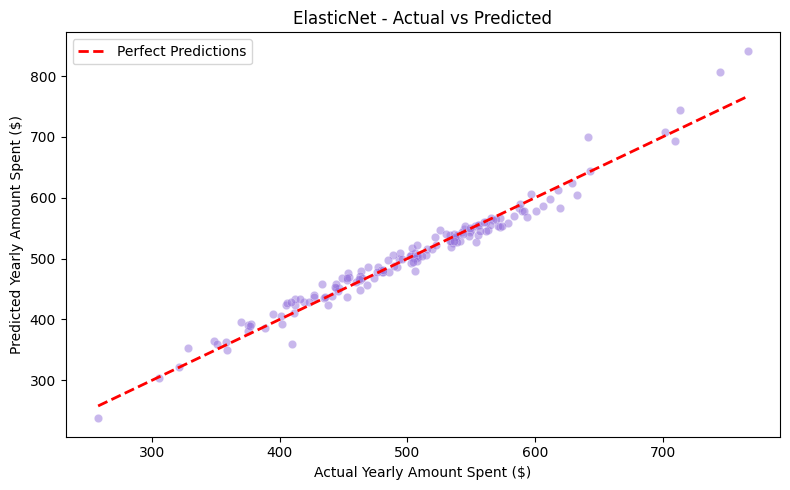

In [203]:
# predict on test set using scaled features
# compute error metrics to evaluate model performance
y_pred_en = elastic_net.predict(X_test_poly3)

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_en, alpha=0.5, color='mediumpurple', edgecolor='white', linewidths=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Predictions') 
plt.xlabel('Actual Yearly Amount Spent ($)')
plt.ylabel('Predicted Yearly Amount Spent ($)')
plt.title('ElasticNet - Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()

### Section 17.3 - Evaluation Metrics

In [199]:
mae_en = mean_absolute_error(y_test, y_pred_en)
mse_en = mean_squared_error(y_test, y_pred_en)
rmse_en = np.sqrt(mse_en)
r2_en = r2_score(y_test, y_pred_en)

print(f"MAE     : {mae_en:.4f}")
print(f"MSE     : {mse_en:.4f}")
print(f"RMSE    : {rmse_en:.4f}")
print(f"R²      : {r2_en:.4f}")

print("\n--- Comparsion: Linear vs Poly=2 vs Poly=3 ---")
print(f"Ridge       R²     : {r2:.4f}    RMSE : {rmse_ridge:.4f}")
print(f"Lasso       R²     : {r2_poly2:.4f}    RMSE : {rmse_lasso:.4f}")
print(f"ElasticNet  R²     : {r2_poly3:.4f}    RMSE : {rmse_en:.4f}")

MAE     : 11.2373
MSE     : 256.0613
RMSE    : 16.0019
R²      : 0.9647

--- Comparsion: Linear vs Poly=2 vs Poly=3 ---
Ridge       R²     : 0.9890    RMSE : 9.8721
Lasso       R²     : 0.9882    RMSE : 9.6540
ElasticNet  R²     : 0.9869    RMSE : 16.0019


### Section 17.4 - Observation
- ElasticNet combines both L1 and L2 penalty equally (l1_ratio=0.5). Its RMSE of 16.00 was the worst of all three regularization methods, suggesting alpha=0.1 was too strong for this dataset, over-penalizing the coefficients and damaging predictions

## Section 18 - Bonus Question

In [210]:
import pandas as pd
# Bonus - Predict Yearly Amount Spent for a new customer
# must scale the new instance using the SAME scaler fitted on training data
# wrapping in DataFrame with column names avoids the feature name warning
new_customer = pd.DataFrame([[35.49726772511229, 12.655651149166752, 39.57766801952616, 4.082620632952961]], columns=X.columns)

new_customer_scaled = scaler.transform(new_customer)
bonus_prediction = lin_reg.predict(new_customer_scaled)
print(f"Predicted Yearly Amount Spent: ${bonus_prediction[0]:.2f}")

Predicted Yearly Amount Spent: $526.04
